# read the three files 
- Ad_Performance.csv, Web_Traffic.csv, and Customer_Transactions.xlsx. 

- Datasets located at: https://raw.githubusercontent.com/ttchuang/dataset/refs/heads/master/Links to an external site.

In [4]:
# set up environment and install necessary libraries
import sys
!{sys.executable} -m pip install numpy pandas scipy matplotlib seaborn
!{sys.executable} -m pip install openpyxl


In [5]:
#conda install scikit-learn

In [18]:
# import necessary libraries and read in datasets
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

ad = pd.read_csv("https://raw.githubusercontent.com/ttchuang/dataset/refs/heads/master/Ad_Performance.csv")
web = pd.read_csv("https://raw.githubusercontent.com/ttchuang/dataset/master/Web_Traffic.csv") 
cust = pd.read_excel("https://raw.githubusercontent.com/ttchuang/dataset/master/Customer_Transactions.xlsx") 
#ad.info()
#web.info()
#cust.info()
#ad.head()
#web.head()
cust.head()

,Customer_ID,Date_of_Order,Order_Value_USD,Acquisition_Channel,Customer_Status,CLV_Flag
0,CUST_0010,2025-09-23,71.41,Facebook/Insta,New,No
1,CUST_0043,2025-09-01,116.70,Google Ads,New,No
2,CUST_0034,2025-09-01,80.85,Facebook/Insta,New,Yes
3,CUST_0183,2025-09-02,43.76,Facebook/Insta,Repeat,No
4,CUST_0273,2025-09-17,107.31,Facebook/Insta,New,No


# 2 Marketing Issues and Analytical Opportunities
## A. Descriptive Analytics: What is happening in our campaigns?



### A_1 Compare total spend, clicks, and conversions by channel, campaign, and date.

In [8]:
ad['Date'] = pd.to_datetime(ad['Date'])
web['Date'] = pd.to_datetime(web['Date'])
cust['Date_of_Order'] = pd.to_datetime(cust['Date_of_Order']) 

channel_total = ad.groupby('Channel').agg({
    'Spend_USD': 'sum',
    'Clicks': 'sum',
    'Conversions': 'sum'
}).reset_index()
campaign_total = ad.groupby('Campaign_ID').agg({
    'Spend_USD': 'sum',
    'Clicks': 'sum',
    'Conversions': 'sum'
}).reset_index()
date_total = ad.groupby('Date').agg({
    'Spend_USD': 'sum',
    'Clicks': 'sum',
    'Conversions': 'sum'
}).reset_index()
print("Total spend, clicks, and conversions by channel:")
print(channel_total)
print("\nTotal spend, clicks, and conversions by campaign:")
print(campaign_total)
print("\nTotal spend, clicks, and conversions by date:")
print(date_total)  

Total spend, clicks, and conversions by channel:
          Channel  Spend_USD  Clicks  Conversions
0  Facebook/Insta    8305.47    8405           71
1      Google Ads   11256.28   25383          731

Total spend, clicks, and conversions by campaign:
        Campaign_ID  Spend_USD  Clicks  Conversions
0     F_Lookalike_T    4427.34    4564           42
1      F_Retarget_C    3878.13    3841           29
2     G_Search_Brnd    3567.19    7781          218
3  G_Search_Generic    4054.84    9147          255
4      G_Shopping_S    3634.25    8455          258

Total spend, clicks, and conversions by date:
         Date  Spend_USD  Clicks  Conversions
0  2025-09-01     539.07     781           16
1  2025-09-02     739.06    1166           19
2  2025-09-03     636.40    1430           38
3  2025-09-04     609.07     898           21
4  2025-09-05     535.37    1141           30
5  2025-09-06     630.02    1287           37
6  2025-09-07     755.70    1408           28
7  2025-09-08     661.7

### A_2 Examine daily trends and seasonality in traffic and conversion.

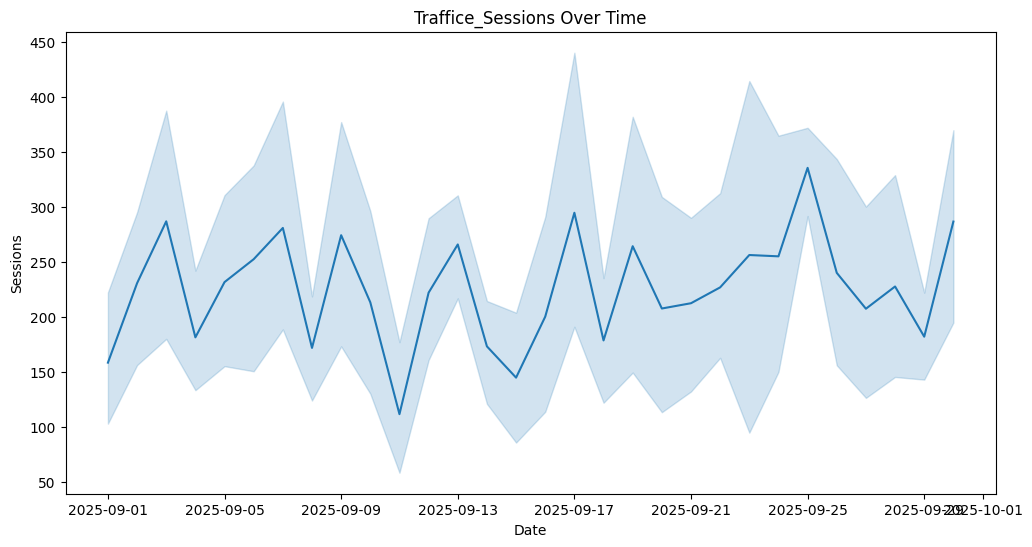

In [9]:
# create a line plot of Sessions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=web, x='Date', y='Sessions')
plt.title('Traffice_Sessions Over Time')
plt.xlabel('Date')
plt.ylabel('Sessions')
#plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

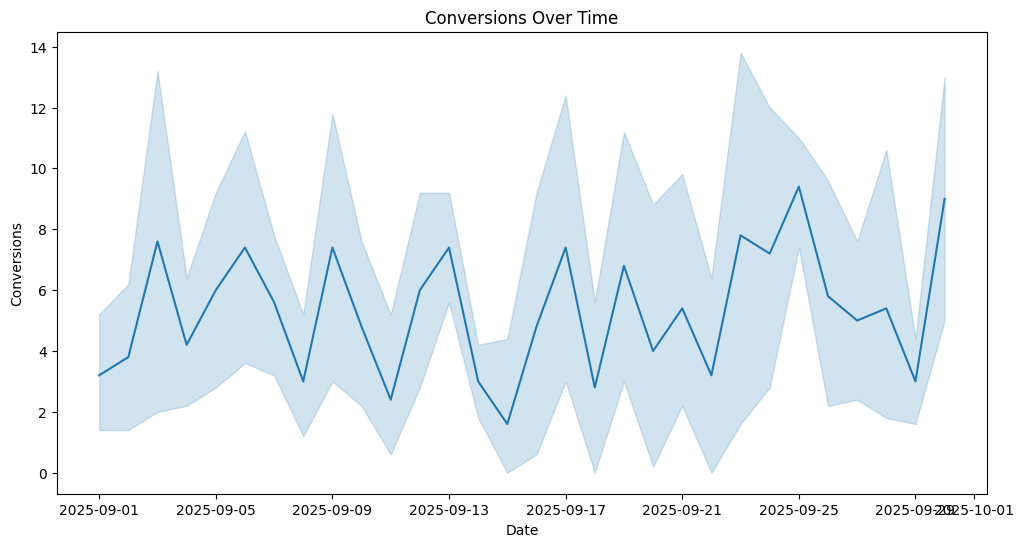

In [10]:
# create a line plot of Conversions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=ad, x='Date', y='Conversions')
plt.title('Conversions Over Time')
plt.xlabel('Date')
plt.ylabel('Conversions')
#plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

### A_3 Identify top-performing campaigns (e.g., by CTR, CVR,CAC).
CTR = Clicks ÷ Impressions （better when higher）
CVR = Conversions ÷ Clicks  （better when higher）
CAC = Ad Spend ÷ New Customers

In [25]:
#Add CTR and CVR to the ad dataset
ad['CTR'] = ad['Clicks'] / ad['Impressions']
ad['CVR'] = ad['Conversions'] / ad['Clicks']
campaign_performance = ad.groupby('Campaign_ID').agg({
    'CTR': 'mean',
    'CVR': 'mean'
}).reset_index()
print("Campaign performance with CTR and CVR:")
print(campaign_performance)
# Calculate CAC
ad_spend_by_channel = ad.groupby('Channel')['Spend_USD'].sum().reset_index()
ad_spend_by_channel.columns = ['Acquisition_Channel', 'Total_Spend']
new_customers = cust[cust['Customer_Status'] == 'New']
new_cust_by_channel = new_customers.groupby('Acquisition_Channel')['Customer_ID'].nunique().reset_index()
new_cust_by_channel.columns = ['Acquisition_Channel', 'New_Customers']
cac_data = pd.merge(ad_spend_by_channel, new_cust_by_channel, on='Acquisition_Channel', how='left')
cac_data['CAC'] = cac_data['Total_Spend'] / cac_data['New_Customers']
#Display final CAC results
print("CAC by Acquisition Channel")
print(cac_data)

Campaign performance with CTR and CVR:
        Campaign_ID       CTR       CVR
0     F_Lookalike_T  0.021096  0.009005
1      F_Retarget_C  0.020341  0.006643
2     G_Search_Brnd  0.044316  0.027735
3  G_Search_Generic  0.045503  0.027206
4      G_Shopping_S  0.046552  0.030195
CAC by Acquisition Channel
  Acquisition_Channel  Total_Spend  New_Customers        CAC
0      Facebook/Insta      8305.47            135  61.522000
1          Google Ads     11256.28            165  68.219879


### A_4 Segment customers by acquisition channel, order frequency, and CLV flag.


In [26]:
# Count unique customers by Acquisition_Channel
channel_summary = cust.groupby('Acquisition_Channel')['Customer_ID'].nunique().reset_index()
channel_summary.columns = ['Acquisition_Channel', 'Customer_Count']
print("1. Customer Count by Acquisition Channel")
print(channel_summary)
print("\n")

# Count unique customers by order frequency(Customer_Status)
status_summary = cust.groupby(['Customer_Status', 'Acquisition_Channel'])['Customer_ID'].nunique().reset_index()
status_summary.columns = ['Customer_Status', 'Acquisition_Channel', 'Customer_Count ']
print("2. Customer Count by Customer Status")
print(status_summary)
print("\n")

# Count unique customers by CLV_Flag(Yes means high value)
clv_summary = cust.groupby(['CLV_Flag', 'Acquisition_Channel'])['Customer_ID'].nunique().reset_index()
clv_summary.columns = ['CLV_Flag', 'Acquisition_Channel', 'Customer_Count']
print("3. Customer Count by CLV Flag(YES means high value)")
print(clv_summary)

1. Customer Count by Acquisition Channel
  Acquisition_Channel  Customer_Count
0      Facebook/Insta             135
1          Google Ads             165


2. Customer Count by Customer Status
  Customer_Status Acquisition_Channel  Customer_Count 
0             New      Facebook/Insta              135
1             New          Google Ads              165
2          Repeat      Facebook/Insta               46
3          Repeat          Google Ads               44


3. Customer Count by CLV Flag(YES means high value)
  CLV_Flag Acquisition_Channel  Customer_Count
0       No      Facebook/Insta             128
1       No          Google Ads             140
2      Yes      Facebook/Insta              16
3      Yes          Google Ads              39


## B. Diagnostic Analytics: Why are some campaigns underperforming?

### B_1 Integrate Ad_Performance.csv with Web_Traffic.csv to explore whether Facebook’s low CVR correlates with high bounce rate or slow page load times.

In [28]:
# Merge Ad_Performance and Web_Traffic
# Unique Key: Date + Channel

ad_web_merged = pd.merge(
    ad, 
    web, 
    on=['Date', 'Channel'], 
    how='inner'
)
# Show the merged result
print("Merged Ad and Web Data")
print(ad_web_merged.head())

Merged Ad and Web Data
         Date     Channel  Campaign_ID_x  Spend_USD  Impressions  Clicks  \
0  2025-09-01  Google Ads  G_Search_Brnd      98.34         5028     241   
1  2025-09-01  Google Ads  G_Search_Brnd      98.34         5028     241   
2  2025-09-01  Google Ads  G_Search_Brnd      98.34         5028     241   
3  2025-09-01  Google Ads   G_Shopping_S     125.92         5166     158   
4  2025-09-01  Google Ads   G_Shopping_S     125.92         5166     158   

   Conversions       CTR       CVR  Campaign_ID_y  Sessions  Bounce_Rate  \
0            5  0.047932  0.020747  G_Search_Brnd       248       0.3439   
1            5  0.047932  0.020747   G_Shopping_S       161       0.3094   
2            5  0.047932  0.020747  G_Search_Brnd       227       0.3371   
3            6  0.030585  0.037975  G_Search_Brnd       248       0.3439   
4            6  0.030585  0.037975   G_Shopping_S       161       0.3094   

   Page_Load_Time_sec  
0                2.69  
1              

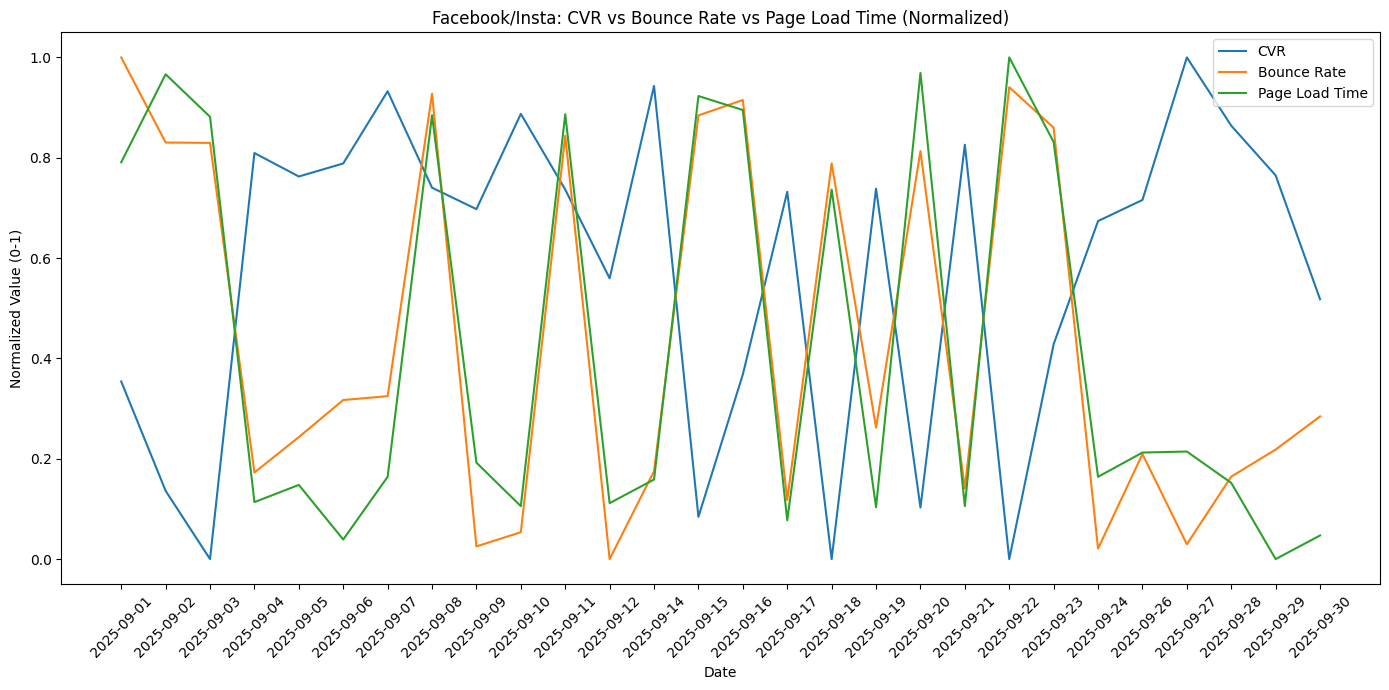

In [ ]:
# Filter Facebook/Insta data only
fb_data = ad_web_merged[ad_web_merged['Channel'] == 'Facebook/Insta'].copy()

# Get daily average metrics
fb_daily = fb_data.groupby('Date').agg({
    'CVR': 'mean',
    'Bounce_Rate': 'mean',
    'Page_Load_Time_sec': 'mean'
}).reset_index()

# Manual normalization (0-1 scaling)
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

fb_daily['CVR_norm'] = normalize(fb_daily['CVR'])
fb_daily['Bounce_Rate_norm'] = normalize(fb_daily['Bounce_Rate'])
fb_daily['Page_Load_Time_norm'] = normalize(fb_daily['Page_Load_Time_sec'])

# Create plot
plt.figure(figsize=(14,7))
sns.lineplot(data=fb_daily, x='Date', y='CVR_norm', label='CVR')
sns.lineplot(data=fb_daily, x='Date', y='Bounce_Rate_norm', label='Bounce Rate')
sns.lineplot(data=fb_daily, x='Date', y='Page_Load_Time_norm', label='Page Load Time')

plt.title('Facebook/Insta: CVR vs Bounce Rate vs Page Load Time (Normalized)')
plt.ylabel('Normalized Value (0-1)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### B_2 Determine whether performance differences are campaign-specific (e.g., Lookalike vs. Retargeting).

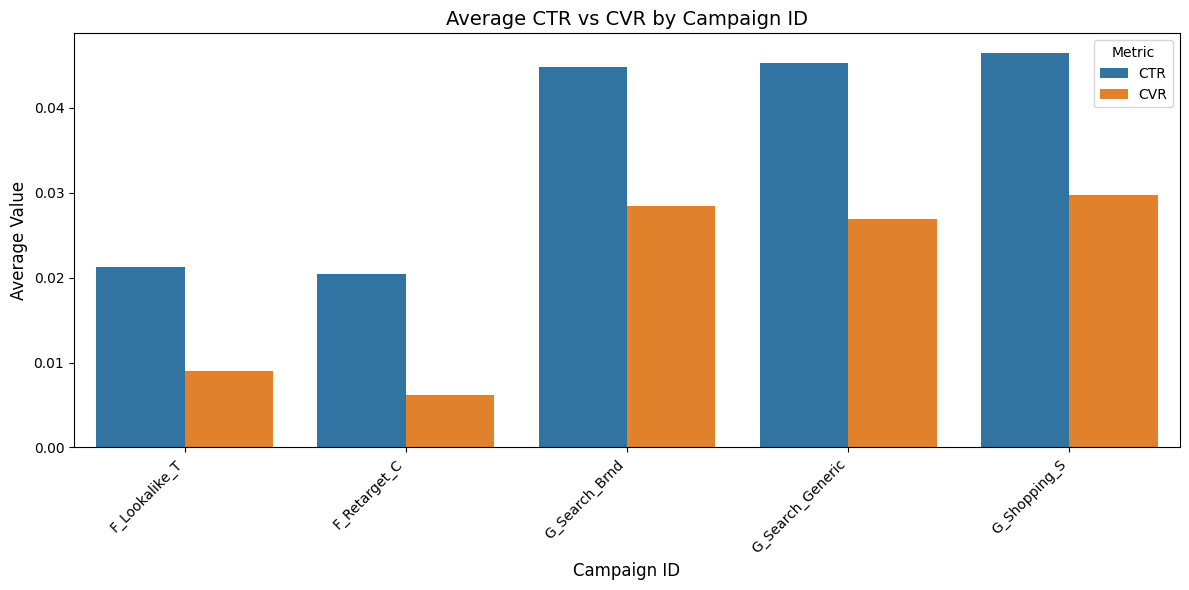

In [ ]:
# Calculate average CTR/CVR by Campaign ID
campaign_metrics = ad_web_merged.groupby('Campaign_ID_x').agg({
    'CTR': 'mean',
    'CVR': 'mean'
}).reset_index()

# Reshape data for dual-bar plot (CTR and CVR side by side)
campaign_melted = campaign_metrics.melt(
    id_vars='Campaign_ID_x',  
    value_vars=['CTR', 'CVR'], 
    var_name='Metric',         
    value_name='Average_Value' 
)

# Create dual-bar plot (two bars per Campaign ID)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=campaign_melted,
    x='Campaign_ID_x',       
    y='Average_Value',       
    hue='Metric',            
    palette=['#1f77b4', '#ff7f0e'] 
)

# Format plot for readability
plt.title('Average CTR vs CVR by Campaign ID', fontsize=14)
plt.ylabel('Average Value', fontsize=12)
plt.xlabel('Campaign ID', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels to avoid overlap
plt.legend(title='Metric', fontsize=10)
plt.tight_layout()  # Fix layout
plt.show()



### B_3 Identify low-CVR days that coincide with technical or content issues.
Clues: Facebook has 5–7 'spike days' with very low CVR (0.5%), high bounce rate (65–80%), and slow load times (4.5–5.5 seconds). Google remains stable.

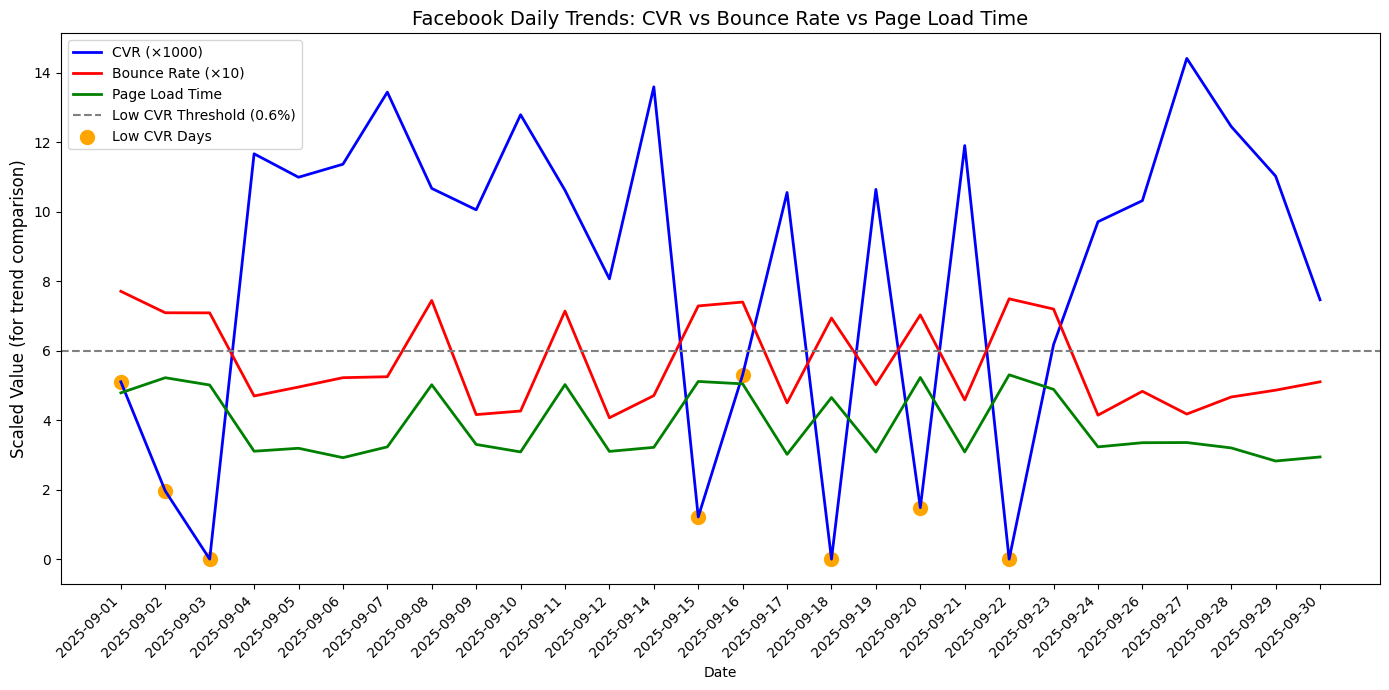

In [30]:
# Aggregate Facebook daily metrics
fb_daily = ad_web_merged[ad_web_merged['Channel'] == 'Facebook/Insta'].groupby('Date').agg({
    'CVR': 'mean',
    'Bounce_Rate': 'mean',
    'Page_Load_Time_sec': 'mean'
}).reset_index()

# Scale metrics for visual alignment (manual adjustment)
fb_daily['CVR_scaled'] = fb_daily['CVR'] * 1000  # Scale CVR to match other metrics
fb_daily['Bounce_scaled'] = fb_daily['Bounce_Rate'] * 10  # Scale bounce rate

# Flag low-CVR days (threshold = 0.6%)
low_cvr_threshold = 0.006
fb_daily['Low_CVR_Day'] = fb_daily['CVR'] < low_cvr_threshold

# Plot trends + highlight low-CVR days
plt.figure(figsize=(14, 7))
# Plot scaled metrics
sns.lineplot(data=fb_daily, x='Date', y='CVR_scaled', color='blue', label='CVR (×1000)', linewidth=2)
sns.lineplot(data=fb_daily, x='Date', y='Bounce_scaled', color='red', label='Bounce Rate (×10)', linewidth=2)
sns.lineplot(data=fb_daily, x='Date', y='Page_Load_Time_sec', color='green', label='Page Load Time', linewidth=2)
# Add threshold line + highlight low-CVR days
plt.axhline(y=low_cvr_threshold*1000, color='gray', linestyle='--', label='Low CVR Threshold (0.6%)')
plt.scatter(data=fb_daily[fb_daily['Low_CVR_Day']], x='Date', y='CVR_scaled', color='orange', s=100, label='Low CVR Days')
# Format plot
plt.title('Facebook Daily Trends: CVR vs Bounce Rate vs Page Load Time', fontsize=14)
plt.ylabel('Scaled Value (for trend comparison)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


# 3. Discussion Questions: Predictive/Prescriptive Analytics
## 3_1 Build a model predicting which customers are High Value. What are the strongest predictors of CLV?
## 3_2 Are high-value customers more likely to come from Google or Facebook? Why might that be?
## 3_3 Based on your findings, how would you reallocate the ad budget for October 2025?
## 3_4 If given an additional $10,000 budget, how should it be split between Google Search, Shopping, and Facebook Retargeting?

# Short reflection